In [2]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam
import os
import numpy as np
from sklearn.metrics import classification_report
from PIL import Image



def build_car_part_classifier(input_shape=(224, 224, 3)):
    model = models.Sequential()

    model.add(layers.Input(shape=input_shape))

    model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(256, activation='relu'))

    model.add(layers.Dense(50, activation='softmax'))

    return model

In [3]:

cnn_model = build_car_part_classifier()
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,257,522 (84.91 MB)

 Trainable params: 22,257,522 (84.91 MB)

 Non-trainable params: 0 (0.00 B)

The custom Convolutional Neural Network employs a Sequential architecture designed for efficient hierarchical feature extraction. The network processes the input data through three consecutive blocks consisting of Conv2D and MaxPooling2D layers. We progressively increased the filter count (32, 64, and 128) across these blocks to allow the network to initially capture simple shapes and edges, and gradually learn highly complex visual patterns specific to car parts. Simultaneously, the max-pooling layers systematically downsample the spatial dimensions from 222x222 down to 26x26, filtering out noise and keeping the computational load manageable. After the Flatten layer transforms the 3D feature maps into a 1D vector of 86,528 elements, a 256-neuron Dense layer acts as the primary decision-making center. Finally, the architecture concludes with a 50-neuron Dense output layer using a softmax activation to output precise probabilities for each of the 50 car part classes.

In [4]:
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [5]:
from data_pipeline import create_dataset_pipeline

# TRAIN_DIR = 'dataset/train'
# VAL_DIR = 'dataset/valid'

TRAIN_DIR = '/content/dataset/train'
VAL_DIR = '/content/dataset/valid'

train_ds = create_dataset_pipeline(TRAIN_DIR, batch_size=32, shuffle=True, augment=False)
val_ds = create_dataset_pipeline(VAL_DIR, batch_size=32, shuffle=False, augment=False)

Found 8739 files belonging to 50 classes.
Found 250 files belonging to 50 classes.


In [6]:
history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 27s 70ms/step - accuracy: 0.2255 - loss: 3.1348 - val_accuracy: 0.4040 - val_loss: 2.3549
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.6064 - loss: 1.4972 - val_accuracy: 0.4520 - val_loss: 2.4155
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.8614 - loss: 0.4921 - val_accuracy: 0.4360 - val_loss: 3.7449
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.9466 - loss: 0.1887 - val_accuracy: 0.4400 - val_loss: 4.7930
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.9733 - loss: 0.0902 - val_accuracy: 0.4440 - val_loss: 5.2663
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.9739 - loss: 0.0945 - val_accuracy: 0.4400 - val_loss: 5.1294
Epoch 7/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.9824 - loss: 0.0679 - val_accuracy: 0.4520 - val_loss: 5.6753
Epoch 8/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.9823 - loss: 0.0631 - 

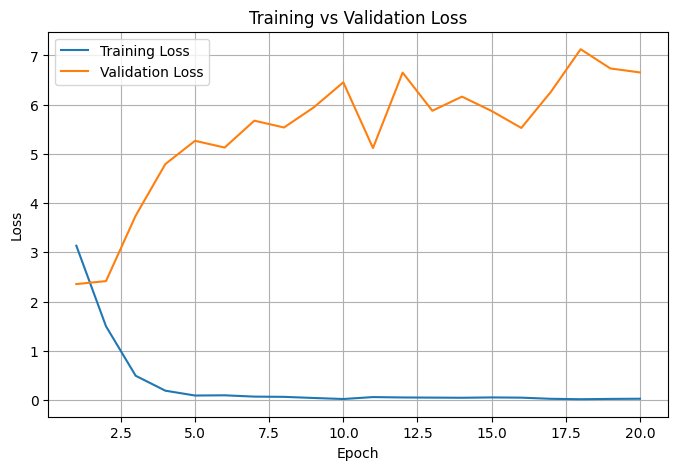

In [7]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history.history['loss'], label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

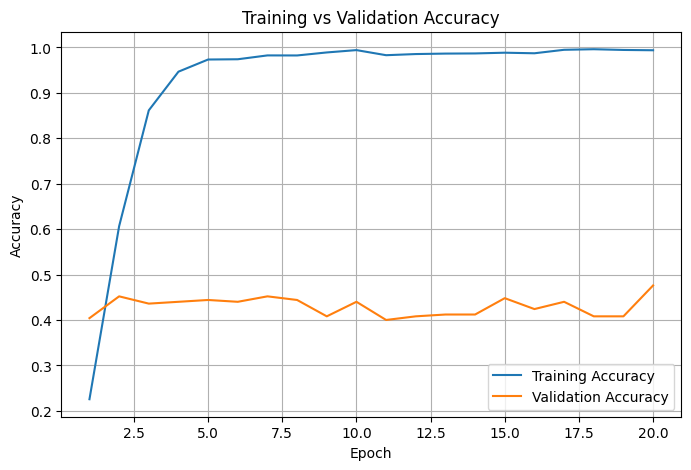

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Is the model overfitting or underfitting?

Obviously, from the charts we can tell the model suffers from overfitting. The validation loss curve keeps increasing with the epochs, while the training loss converges to zero. As expected, the second plot mirrors this: training accuracy climbs up to 99%, which is rarely a good outcome, especially when the validation accuracy oscillates between 0.4 and 0.5. So the clear answer: yes — the model is overfitted.

At which epoch is validation performance best?

I would say somewhere around epoch 8. In the accuracy plot, the validation line increases up to 0.49 at epoch 8, then stays around that value for the rest of the training. In the loss plot, the orange line decreases until the end of the second epoch, then keeps growing. The two criteria disagree, which is a common symptom of overfitting — the model becomes more confident about wrong predictions even when raw accuracy holds. Although performance can be measured directly with the loss function, I think the question targets performance metrics like accuracy.

Research and list at least 3 techniques to prevent overfitting (Dropout, Augmentation, Early Stopping, BatchNorm, Regularization).

Dropout can be applied both to convolutional layers and to the dense layers of a CNN. The typical rate is in the range of 0.2 to 0.3. In convolutional layers we don't have neurons to drop (in an ANN, dropping a neuron means deactivating it — its output becomes zero), so instead we drop an entire feature map that has learned a pattern. This technique relies on the idea that the model is forced not to depend on a specific set of neurons or feature maps. That makes it more robust at inference, in the sense that it generalises better.

Augmentation is the technique we use to fight overfitting by applying transformations (such as rotation of the input images) to the training set. This method helps because the model is forced to recognize the target element (in our case, a car part) despite the noise we introduce on purpose. As a result, the CNN learns to generalise its predictions better. Augmentation is applied only to the training set, not to validation or test data.

Early Stopping is very simple to understand and implement, yet a powerful thing to do when we face overfitting. The concept is: when the performance on the training set keeps improving while the performance on the validation set gets worse, we stop. That's a clue the model is starting to learn the training data too precisely, and we don't want that. In practice, we stop after patience epochs without improvement (to avoid stopping on a random dip), and we restore the model weights from the best epoch.

BatchNorm normalizes the outputs between layers based on the mean and variance computed from the current batch, then rescales them with two trainable parameters (γ and β). It stabilizes training and mitigates the vanishing/exploding gradient problem. The regularizing noise comes from the fact that per-batch statistics vary between batches, so the same input is normalized slightly differently each time. This small variability acts as a mild regularizer — the network cannot rely on exact activation values, which discourages overfitting to specific training patterns and helps the model generalize better.

Regularization is a general term for any technique that adds a constraint to the model in order to prevent overfitting. In the strict sense, it refers to L1/L2 weight regularization, which adds a penalty term to the loss based on the size of the weights. This forces the model to prefer smaller weights, which produce smoother decision boundaries and reduce sensitivity to noise in the training data. As a result, the model is less likely to memorize specific training patterns and generalizes better on unseen data.

In [9]:
TEST_DIR = 'dataset/test'
test_ds = create_dataset_pipeline(TEST_DIR, batch_size=32, shuffle=False, augment=False)

class_names = sorted(os.listdir(TEST_DIR))

y_true, y_pred = [], []
for x_batch, y_batch in test_ds:
    preds = cnn_model.predict(x_batch, verbose=0)
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))

Found 250 files belonging to 50 classes.
                      precision    recall  f1-score   support

      AIR COMPRESSOR      0.400     0.400     0.400         5
          ALTERNATOR      0.333     0.400     0.364         5
             BATTERY      0.800     0.800     0.800         5
       BRAKE CALIPER      0.250     0.200     0.222         5
           BRAKE PAD      0.667     0.400     0.500         5
         BRAKE ROTOR      0.500     0.400     0.444         5
            CAMSHAFT      0.429     0.600     0.500         5
          CARBERATOR      0.375     0.600     0.462         5
        CLUTCH PLATE      1.000     0.800     0.889         5
         COIL SPRING      0.750     0.600     0.667         5
          CRANKSHAFT      0.556     1.000     0.714         5
       CYLINDER HEAD      0.000     0.000     0.000         5
         DISTRIBUTOR      0.125     0.200     0.154         5
        ENGINE BLOCK      0.333     0.600     0.429         5
        ENGINE VALVE      1.

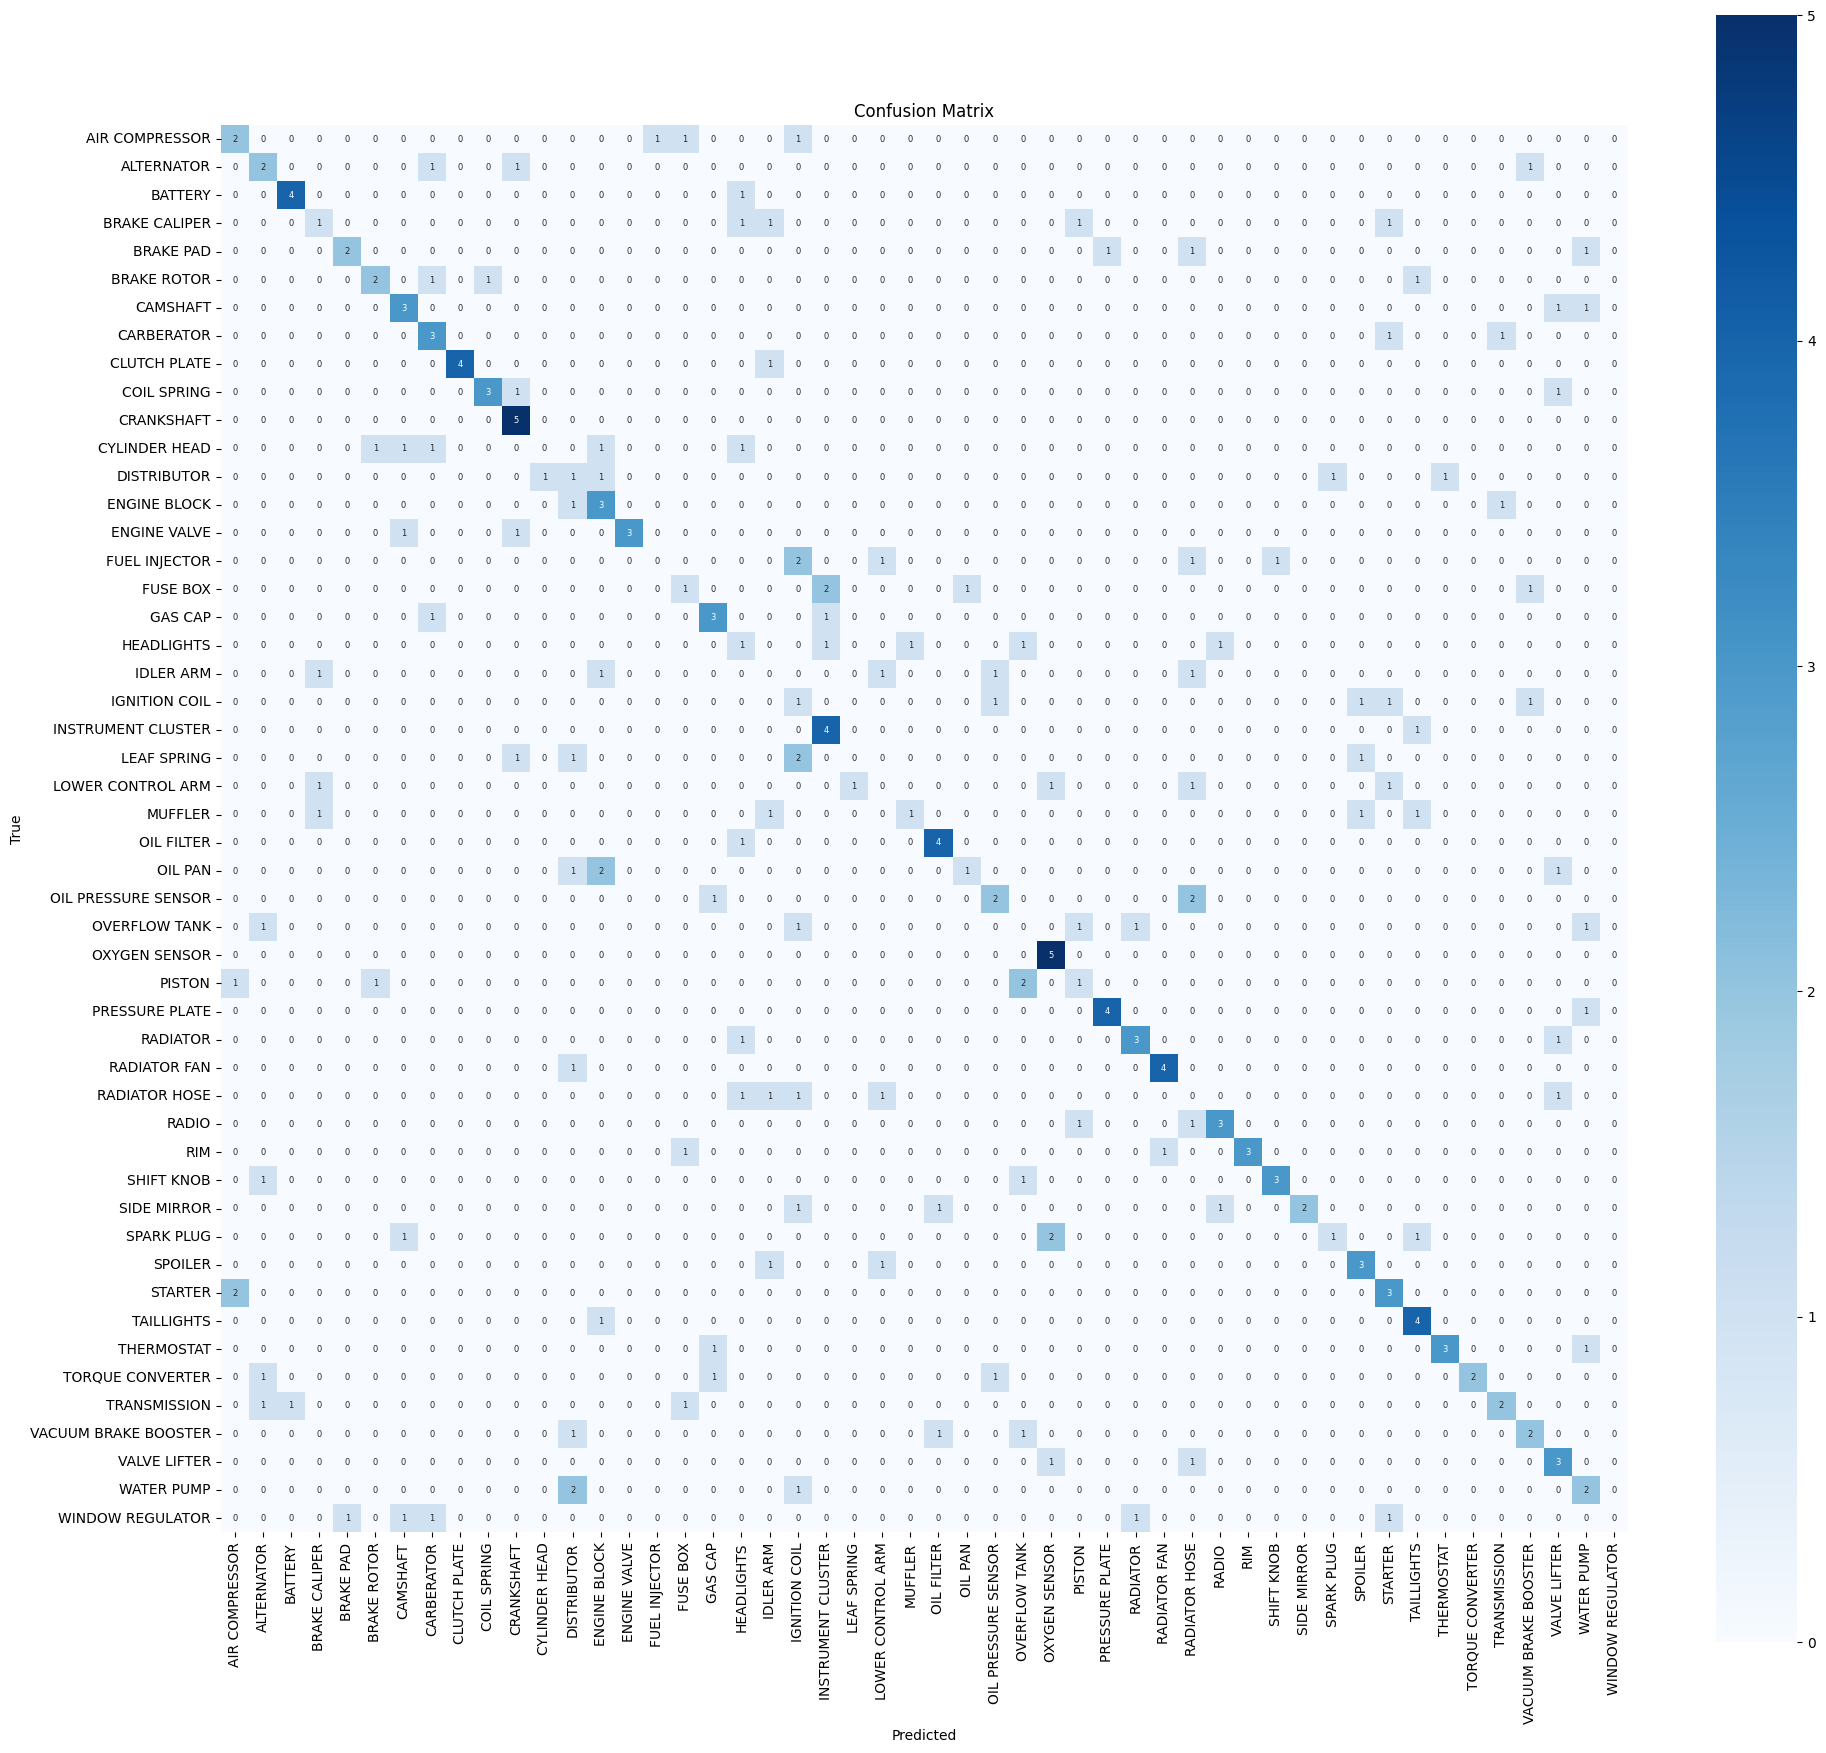

In [10]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues',
    cbar=True,
    square=True,
    annot=True,
    fmt='d',
    annot_kws={'size': 6}
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

top_confusions = np.dstack(
    np.unravel_index(
        np.argsort(cm_no_diag.ravel())[::-1][:3],
        cm.shape
    )
)[0]

for i, (true_idx, pred_idx) in enumerate(top_confusions, 1):
    count = cm_no_diag[true_idx, pred_idx]
    print(f"{i}. True: {class_names[true_idx]} → Predicted: {class_names[pred_idx]} ({count} cases)")

1. True: STARTER → Predicted: AIR COMPRESSOR (2 cases)
2. True: OIL PAN → Predicted: ENGINE BLOCK (2 cases)
3. True: PISTON → Predicted: OVERFLOW TANK (2 cases)


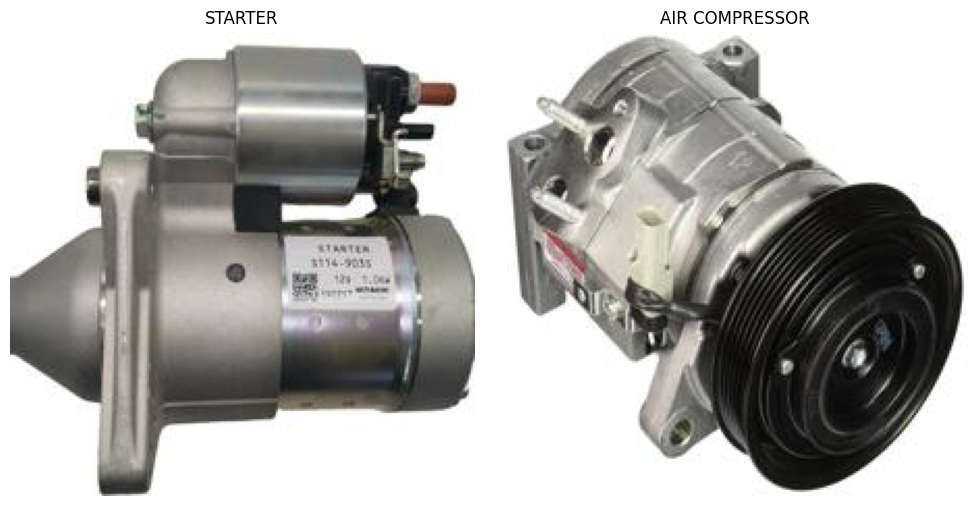

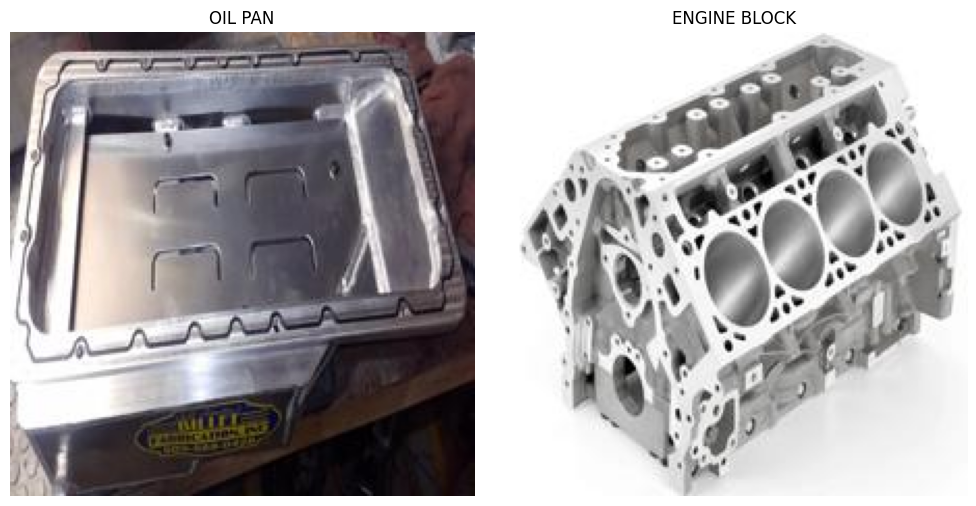

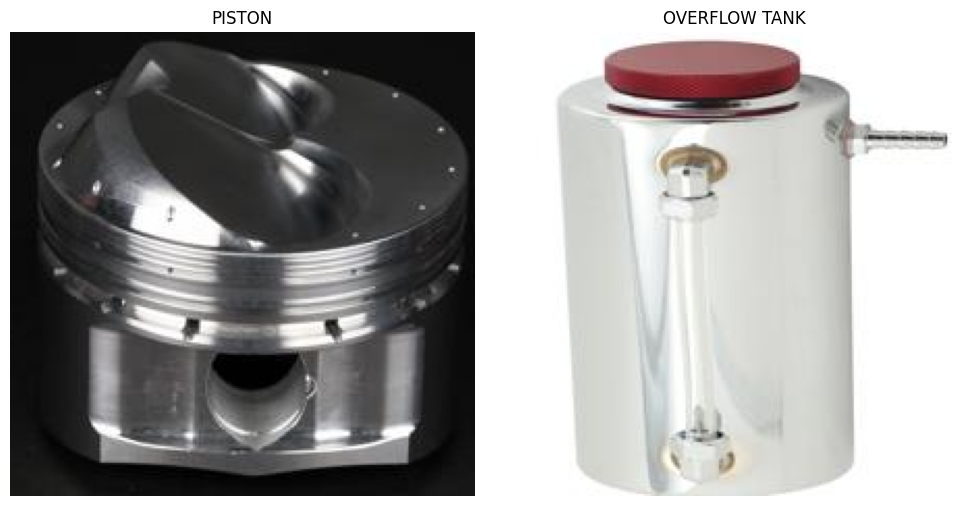

In [12]:
def show_pair(class_a, class_b, base_dir='dataset/test'):
    img_a = os.listdir(os.path.join(base_dir, class_a))[0]
    img_b = os.listdir(os.path.join(base_dir, class_b))[0]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(Image.open(os.path.join(base_dir, class_a, img_a)))
    axes[0].set_title(class_a)
    axes[0].axis('off')
    axes[1].imshow(Image.open(os.path.join(base_dir, class_b, img_b)))
    axes[1].set_title(class_b)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

pairs = [(class_names[true_idx], class_names[pred_idx]) for true_idx, pred_idx in top_confusions]

for a, b in pairs:
    show_pair(a, b)

Overall accuracy on the test set: 0.48. Only 48% of the 250 test images are classified correctly, which reflects the severe overfitting already observed during training — the model memorized the training data but fails to generalize to unseen images.

The confusion matrix is a 50×50 grid where the rows represent the true class and the columns represent the predicted class.The diagonal represents correct predictions. In a well-performing model, the diagonal should be strongly dominant, with almost all color concentrated there. In our heatmap, the diagonal is weak and inconsistent: some classes have visible diagonal cells, while many others are barely distinguishable from surrounding noise. This confirms that the model is not able to consistently separate the 50 classes.

By F1-score, the following classes are the weakest:
LEAF SPRING — 0.000
OIL PAN — 0.000
WATER PUMP — 0.000
IGNITION COIL — 0.143
RADIATOR HOSE — 0.167
For the first three classes the model never produces a correct prediction, which is the worst possible outcome. The remaining two are correctly predicted only in a small minority of cases.

Top confused class pairs: across multiple runs, the pairs that dominate the top confusions tend to share the same kind of visual traits — very similar overall shapes and silhouettes, and in some cases similar colors or metallic textures as well. The exact pairs vary from run to run, but the pattern is consistent: the model is picking up generic low-level features (color, texture, silhouette) instead of the fine-grained structural differences that truly distinguish the parts.


In [13]:
train_ds_aug = create_dataset_pipeline(TRAIN_DIR, batch_size=32, shuffle=True, augment=True)

cnn_aug = build_car_part_classifier()
cnn_aug.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_aug = cnn_aug.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=20
)

Found 8739 files belonging to 50 classes.
Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 104s 357ms/step - accuracy: 0.1221 - loss: 3.4854 - val_accuracy: 0.2080 - val_loss: 3.3175
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 97s 351ms/step - accuracy: 0.3253 - loss: 2.5439 - val_accuracy: 0.4640 - val_loss: 2.0987
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 141s 348ms/step - accuracy: 0.4045 - loss: 2.1695 - val_accuracy: 0.4560 - val_loss: 2.2788
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 95s 346ms/step - accuracy: 0.4600 - loss: 1.9393 - val_accuracy: 0.5240 - val_loss: 1.8440
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 96s 348ms/step - accuracy: 0.5199 - loss: 1.7550 - val_accuracy: 0.5280 - val_loss: 1.9653
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 96s 351ms/step - accuracy: 0.5546 - loss: 1.6081 - val_accuracy: 0.5720 - val_loss: 1.7190
Epoch 7/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 95s 345ms/step - accuracy: 0.5791 - loss: 1.4888 - val_accuracy: 0.5680 - val_loss: 1.6664
Epoch 8/20
274/274 ━━━━━━━━━━━━━━━━━━━━

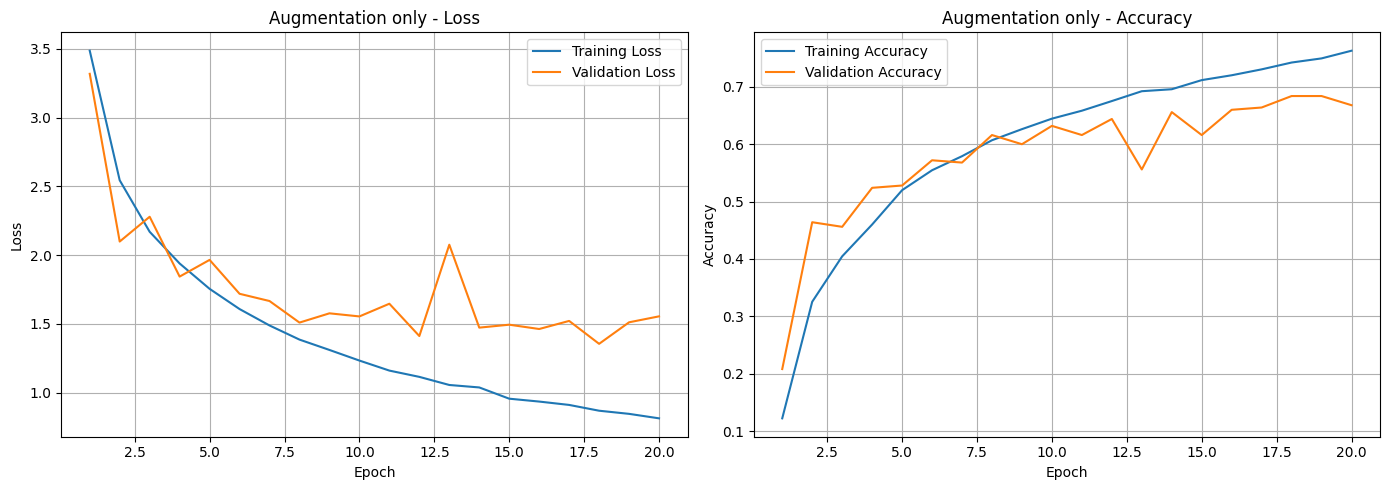

In [14]:
epochs_range_aug = range(1, len(history_aug.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range_aug, history_aug.history['loss'], label='Training Loss')
axes[0].plot(epochs_range_aug, history_aug.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Augmentation only - Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range_aug, history_aug.history['accuracy'], label='Training Accuracy')
axes[1].plot(epochs_range_aug, history_aug.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Augmentation only - Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [15]:
def build_car_part_classifier_dropout(input_shape=(224, 224, 3)):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))

    model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(50, activation='softmax'))
    return model

cnn_aug_dropout = build_car_part_classifier_dropout()
cnn_aug_dropout.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_aug_dropout = cnn_aug_dropout.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 107s 363ms/step - accuracy: 0.0483 - loss: 3.8643 - val_accuracy: 0.1080 - val_loss: 3.6209
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 93s 339ms/step - accuracy: 0.0943 - loss: 3.5470 - val_accuracy: 0.1560 - val_loss: 3.3975
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 94s 343ms/step - accuracy: 0.1403 - loss: 3.2935 - val_accuracy: 0.2400 - val_loss: 2.9633
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 94s 343ms/step - accuracy: 0.1888 - loss: 3.0936 - val_accuracy: 0.2240 - val_loss: 3.1099
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 145s 353ms/step - accuracy: 0.2237 - loss: 2.9167 - val_accuracy: 0.2760 - val_loss: 2.7247
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 98s 354ms/step - accuracy: 0.2527 - loss: 2.7897 - val_accuracy: 0.3480 - val_loss: 2.4670
Epoch 7/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 138s 342ms/step - accuracy: 0.2854 - loss: 2.6449 - val_accuracy: 0.3560 - val_loss: 2.5775
Epoch 8/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 94s 343ms/step - accuracy: 0.3063 - loss

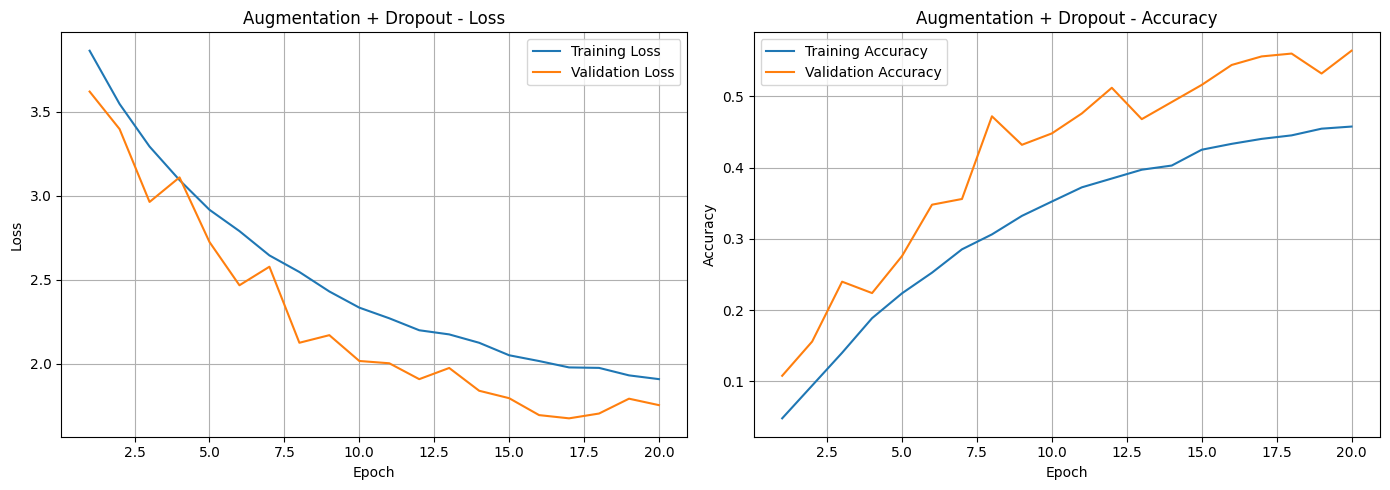

In [16]:
epochs_range_aug_dropout = range(1, len(history_aug_dropout.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range_aug_dropout, history_aug_dropout.history['loss'], label='Training Loss')
axes[0].plot(epochs_range_aug_dropout, history_aug_dropout.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Augmentation + Dropout - Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range_aug_dropout, history_aug_dropout.history['accuracy'], label='Training Accuracy')
axes[1].plot(epochs_range_aug_dropout, history_aug_dropout.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Augmentation + Dropout - Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [17]:
baseline_test_loss, baseline_test_acc = cnn_model.evaluate(test_ds, verbose=0)
aug_dropout_test_loss, aug_dropout_test_acc = cnn_aug_dropout.evaluate(test_ds, verbose=0)

print(f'Baseline (M3.3)        - test accuracy: {baseline_test_acc:.4f} | test loss: {baseline_test_loss:.4f}')
print(f'Augmentation + Dropout - test accuracy: {aug_dropout_test_acc:.4f} | test loss: {aug_dropout_test_loss:.4f}')

Baseline (M3.3)        - test accuracy: 0.4360 | test loss: 6.2050
Augmentation + Dropout - test accuracy: 0.5360 | test loss: 1.7122


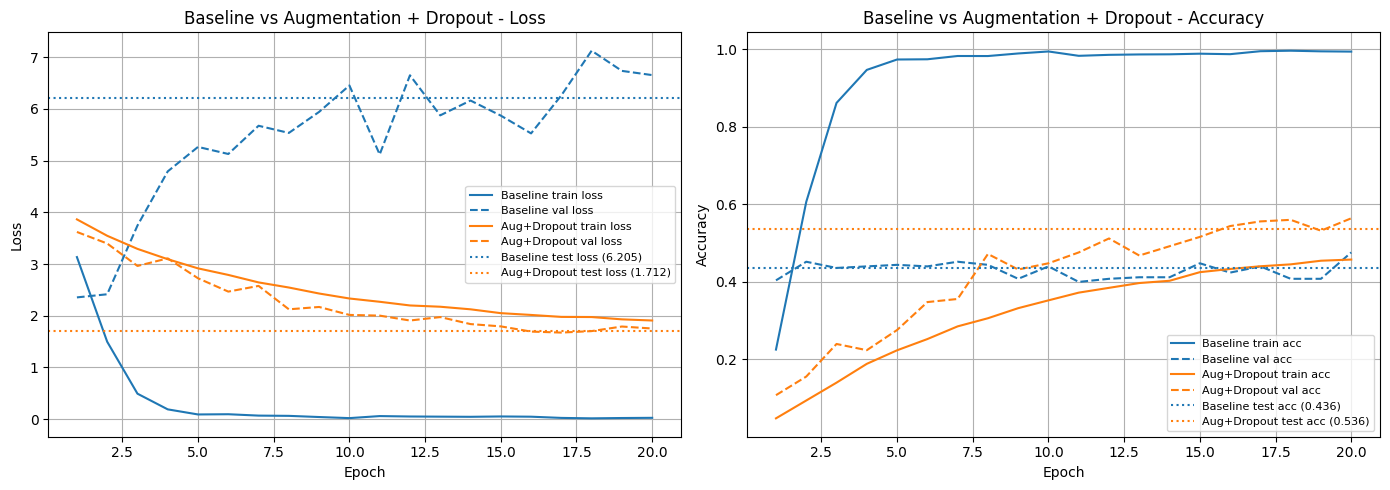

In [18]:
baseline_epochs = range(1, len(history.history['loss']) + 1)
aug_dropout_epochs = range(1, len(history_aug_dropout.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(baseline_epochs, history.history['loss'], label='Baseline train loss', color='tab:blue')
axes[0].plot(baseline_epochs, history.history['val_loss'], label='Baseline val loss', color='tab:blue', linestyle='--')
axes[0].plot(aug_dropout_epochs, history_aug_dropout.history['loss'], label='Aug+Dropout train loss', color='tab:orange')
axes[0].plot(aug_dropout_epochs, history_aug_dropout.history['val_loss'], label='Aug+Dropout val loss', color='tab:orange', linestyle='--')
axes[0].axhline(baseline_test_loss, color='tab:blue', linestyle=':', label=f'Baseline test loss ({baseline_test_loss:.3f})')
axes[0].axhline(aug_dropout_test_loss, color='tab:orange', linestyle=':', label=f'Aug+Dropout test loss ({aug_dropout_test_loss:.3f})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Baseline vs Augmentation + Dropout - Loss')
axes[0].legend(fontsize=8)
axes[0].grid(True)

axes[1].plot(baseline_epochs, history.history['accuracy'], label='Baseline train acc', color='tab:blue')
axes[1].plot(baseline_epochs, history.history['val_accuracy'], label='Baseline val acc', color='tab:blue', linestyle='--')
axes[1].plot(aug_dropout_epochs, history_aug_dropout.history['accuracy'], label='Aug+Dropout train acc', color='tab:orange')
axes[1].plot(aug_dropout_epochs, history_aug_dropout.history['val_accuracy'], label='Aug+Dropout val acc', color='tab:orange', linestyle='--')
axes[1].axhline(baseline_test_acc, color='tab:blue', linestyle=':', label=f'Baseline test acc ({baseline_test_acc:.3f})')
axes[1].axhline(aug_dropout_test_acc, color='tab:orange', linestyle=':', label=f'Aug+Dropout test acc ({aug_dropout_test_acc:.3f})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Baseline vs Augmentation + Dropout - Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()

Loss comparison. In the baseline model, the validation loss grows progressively across epochs, while the training loss quickly drops toward zero. This gap is a textbook overfitting signature — the model is not actually learning generalizable features; it memorizes the training set. As soon as a car part appears in a slightly different pose or lighting, the prediction breaks. The test loss confirms this: the baseline reaches a very high test loss of ~6.2, which is essentially useless.

The augmentation + dropout run tells a different story. Training and validation loss curves stay close together and both decrease steadily, without the divergence seen in the baseline. Neither curve is anywhere near zero, which is expected — dropout deactivates a large fraction of the units at every step, so the network needs more updates to fit the data. Given the same 20-epoch budget as the baseline, the regularized model was still improving at the end, and it likely would have kept improving with more epochs. The important part is that the test loss drops to ~1.7, roughly 4x lower than the baseline, which shows the model is finally generalizing instead of memorizing.

Augmentation alone already helps: without dropout, the training loss drops to ~0.8 and the validation loss stabilizes around ~1.5, without the runaway divergence seen in the baseline — a clear sign that the augmented samples force the network to learn features that transfer to unseen images.

Accuracy comparison. On the accuracy chart, the baseline training curve shoots up close to 1.0 within a few epochs — the direct consequence of the overfitting already discussed — while its validation accuracy plateaus at roughly the same level as its test accuracy (~0.44). All the extra confidence gained on the training set never transfers to unseen data.

Augmentation alone lifts validation accuracy up to ~0.68, which is a large jump; the augmented samples force the network to learn features that actually generalize.

Augmentation + dropout climbs slowly and progressively, without overfitting the training set. Validation accuracy trends toward ~0.56 and test accuracy lands at 0.536 — about 10 percentage points above the baseline. The lower peak compared to augmentation-only is expected: dropout deactivates a large fraction of the units at every step and slows learning, so with the same 20-epoch budget the model has not yet converged. With more epochs, this run would likely close the gap and eventually surpass the augmentation-only variant thanks to the extra regularization.